# Notebook 2 - Splitting and Preprocessing

This notebook takes the cleaned subset from Notebook 1, creates train/validation/test splits, encodes labels, builds preprocessing variants, and saves the artifacts needed for training and deployment.

# Step 0 - Imports

Load the libraries used for splitting, preprocessing, feature checks, and saving artifacts.

The code below imports tools for splitting, scaling, encoding labels, plotting, and saving JSON/pickle artifacts.

In [1]:
from pathlib import Path
import gc
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils.class_weight import compute_class_weight

# Step 1 - Load the Cleaned Subset

Load the subset created in Notebook 1 using project-relative paths. This keeps the notebook portable across machines.

The code below finds the project folders, loads `subset_cleaned.csv`, and prints the loaded shape.

In [2]:
_cwd = Path.cwd()
if (_cwd / "data").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "data").exists():
    PROJECT_ROOT = _cwd.parent
else:
    raise RuntimeError(f"Cannot locate project root from {_cwd}. "
                       "Open the notebook from inside the project folder.")

SUBSET_DIR      = PROJECT_ROOT / "data" / "subset"
subset_csv_path = SUBSET_DIR / "subset_cleaned.csv"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Project root   :", PROJECT_ROOT)
print("Subset dir     :", SUBSET_DIR)
print("Subset CSV     :", subset_csv_path)
print("RANDOM_STATE   :", RANDOM_STATE)

df = pd.read_csv(subset_csv_path)

print("\nLoaded subset shape:", df.shape)
df.head(3)

Project root   : C:\Users\user\Desktop\MyFiles\Uni\My_ML_Project
Subset dir     : C:\Users\user\Desktop\MyFiles\Uni\My_ML_Project\data\subset
Subset CSV     : C:\Users\user\Desktop\MyFiles\Uni\My_ML_Project\data\subset\subset_cleaned.csv
RANDOM_STATE   : 42



Loaded subset shape: (1288384, 40)


,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,Label
0,19.2,6,78.2,26.343731,0.0,0.0,0.0,0.1,0.6,0.0,...,787.0,60.0,156.0,78.7,32.694036,78.7,0.046628,10.0,1068.900000,BACKDOOR_MALWARE
1,27.2,6,57.6,229.880300,0.1,0.2,0.0,0.1,0.7,0.0,...,1172.0,60.0,367.0,117.2,107.987448,117.2,0.004890,10.0,11661.288889,BACKDOOR_MALWARE
2,23.6,6,144.2,38.947328,0.1,0.3,0.0,0.1,0.4,0.0,...,1395.0,66.0,349.0,139.5,114.507884,139.5,0.025676,10.0,13112.055556,BACKDOOR_MALWARE


# Step 2 - Sanity Check

Confirm the dataset loaded correctly and that the target column exists. These checks catch file or column issues early.

The code below asserts that `Label` exists and prints a quick dataset summary.

In [3]:
TARGET_COL = "Label"

assert TARGET_COL in df.columns, (
    f"Target column '{TARGET_COL}' not found. "
    f"Available columns: {df.columns.tolist()}"
)

print("Dataset shape      :", df.shape)
print("Target column      :", TARGET_COL)
print("Number of columns  :", df.shape[1])
print("Number of classes  :", df[TARGET_COL].nunique())
print("Missing labels     :", df[TARGET_COL].isna().sum())
print("Exact duplicates   :", df.duplicated().sum())


Dataset shape      : (1288384, 40)
Target column      : Label
Number of columns  : 40
Number of classes  : 34
Missing labels     : 0


Exact duplicates   : 0


# Step 3 - Define Features and Target

Separate the input features `X` from the label column `y`. The model learns from `X` and tries to predict `y`.

The code below drops the target column from `X` and stores the labels separately in `y`.

In [4]:
X = df.drop(columns=TARGET_COL).copy()
y = df[TARGET_COL].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of feature columns:", X.shape[1])

print("\nFeature columns preview:")
print(X.columns.tolist()[:20])

print("\nTarget preview:")
print(y.value_counts().head())

X shape:

 (1288384, 39)
y shape: (1288384,)
Number of feature columns: 39

Feature columns preview:
['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP']

Target preview:
Label
BENIGN                     50000
DDOS-ACK_FRAGMENTATION     50000
DDOS-ICMP_FLOOD            50000
DDOS-ICMP_FRAGMENTATION    50000
DDOS-PSHACK_FLOOD          50000
Name: count, dtype: int64


# Step 4 - Train / Validation / Test Split

Split the data into training, validation, and test sets. We stratify by class so each split keeps the same label balance as much as possible.

The code below performs a stratified 70/15/15 split and keeps the random seed fixed.

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,          # 30% goes to temp
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape :", X_train.shape, y_train.shape)
print("Temp shape  :", X_temp.shape, y_temp.shape)

Train shape : (901868, 39) (901868,)
Temp shape  : (386516, 39) (386516,)


In [6]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,         
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train shape :", X_train.shape, y_train.shape)
print("Val shape   :", X_val.shape, y_val.shape)
print("Test shape  :", X_test.shape, y_test.shape)

Train shape : (901868, 39) (901868,)
Val shape   : (193258, 39) (193258,)
Test shape  : (193258, 39) (193258,)


# Step 5 - Post-Split Sanity Checks

Check shapes and class coverage after splitting. This confirms that every class is still represented in train, validation, and test.

The code below prints split sizes and checks that class coverage was preserved.

In [7]:
print("=== SPLIT SHAPES ===")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape} | y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape} | y_test : {y_test.shape}")

train_labels = set(y_train.unique())
val_labels = set(y_val.unique())
test_labels = set(y_test.unique())

print("\n=== LABEL COVERAGE ===")
print("Classes in train:", len(train_labels))
print("Classes in val  :", len(val_labels))
print("Classes in test :", len(test_labels))

print("\nMissing from val :", sorted(train_labels - val_labels))
print("Missing from test:", sorted(train_labels - test_labels))

=== SPLIT SHAPES ===
X_train: (901868, 39) | y_train: (901868,)
X_val  : (193258, 39) | y_val  : (193258,)
X_test : (193258, 39) | y_test : (193258,)

=== LABEL COVERAGE ===
Classes in train: 34
Classes in val  : 34
Classes in test : 34

Missing from val : []
Missing from test: []


In [8]:
def build_class_dist(y_split, split_name):
    counts = y_split.value_counts(dropna=False).sort_values(ascending=False)
    pct = (counts / len(y_split) * 100).round(4)
    out = pd.DataFrame({
        "class": counts.index,
        f"count_{split_name}": counts.values,
        f"pct_{split_name}": pct.values
    })
    return out

train_dist = build_class_dist(y_train, "train")
val_dist   = build_class_dist(y_val, "val")
test_dist  = build_class_dist(y_test, "test")

split_dist_comparison = (
    train_dist
    .merge(val_dist, on="class", how="outer")
    .merge(test_dist, on="class", how="outer")
    .fillna(0)
)

display(split_dist_comparison)

,class,count_train,pct_train,count_val,pct_val,count_test,pct_test
0,BACKDOOR_MALWARE,2152,0.2386,461,0.2385,462,0.2391
1,BENIGN,35000,3.8808,7500,3.8808,7500,3.8808
2,BROWSERHIJACKING,3892,0.4315,834,0.4315,834,0.4315
3,COMMANDINJECTION,3605,0.3997,773,0.4000,772,0.3995
4,DDOS-ACK_FRAGMENTATION,35000,3.8808,7500,3.8808,7500,3.8808
5,DDOS-HTTP_FLOOD,19318,2.1420,4139,2.1417,4140,2.1422
6,DDOS-ICMP_FLOOD,35000,3.8808,7500,3.8808,7500,3.8808
7,DDOS-ICMP_FRAGMENTATION,35000,3.8808,7500,3.8808,7500,3.8808
8,DDOS-PSHACK_FLOOD,35000,3.8808,7500,3.8808,7500,3.8808
9,DDOS-RSTFINFLOOD,35000,3.8808,7500,3.8808,7500,3.8808


# Step 6 - Label Encoding

Convert string labels into integer class IDs. Models need numeric targets, and the saved mapping lets us translate predictions back to class names.

The code below fits the label encoder on training labels and transforms train, validation, and test labels.

In [9]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded   = label_encoder.transform(y_val)
y_test_encoded  = label_encoder.transform(y_test)

print("Label encoding completed.")
print("Number of classes:", len(label_encoder.classes_))

Label encoding completed.
Number of classes: 34


In [10]:
label_mapping_df = pd.DataFrame({
    "class_name": label_encoder.classes_,
    "class_id": range(len(label_encoder.classes_))
})

display(label_mapping_df)

,class_name,class_id
0,BACKDOOR_MALWARE,0
1,BENIGN,1
2,BROWSERHIJACKING,2
3,COMMANDINJECTION,3
4,DDOS-ACK_FRAGMENTATION,4
5,DDOS-HTTP_FLOOD,5
6,DDOS-ICMP_FLOOD,6
7,DDOS-ICMP_FRAGMENTATION,7
8,DDOS-PSHACK_FLOOD,8
9,DDOS-RSTFINFLOOD,9


In [11]:
print("Encoded train labels shape:", y_train_encoded.shape)
print("Encoded val labels shape  :", y_val_encoded.shape)
print("Encoded test labels shape :", y_test_encoded.shape)

print("\nTrain label ID sample:")
print(pd.Series(y_train_encoded).value_counts().sort_index().head(10))

Encoded train labels shape: (901868,)
Encoded val labels shape  : (193258,)
Encoded test labels shape : (193258,)

Train label ID sample:
0     2152
1    35000
2     3892
3     3605
4    35000
5    19318
6    35000
7    35000
8    35000
9    35000
Name: count, dtype: int64


# Step 7 - Create Dataset Variants

Keep multiple feature versions because models react differently to scaling and outlier handling. Later notebooks can choose the variant that fits each model best.

The code below creates copies for the raw, outlier-clipped, scaled, and outlier+scaled variants.

In [12]:
# Raw versions (no outlier handling, no scaling)
X_train_raw = X_train.copy()
X_val_raw   = X_val.copy()
X_test_raw  = X_test.copy()

# Outlier-treatment versions (will be modified later)
X_train_out = X_train.copy()
X_val_out   = X_val.copy()
X_test_out  = X_test.copy()

# Scaled-only versions (will be created later from raw)
X_train_scaled = None
X_val_scaled   = None
X_test_scaled  = None

# Outlier + scaled versions (will be created later from outlier-treated data)
X_train_out_scaled = None
X_val_out_scaled   = None
X_test_out_scaled  = None

print("Feature-set copies initialized.")
print("\nAvailable variants:")
print("- X_train_raw / X_val_raw / X_test_raw           -> no outlier treatment, no scaling")
print("- X_train_out / X_val_out / X_test_out           -> reserved for outlier treatment")
print("- X_train_scaled / X_val_scaled / X_test_scaled  -> will be scaling only")
print("- X_train_out_scaled / X_val_out_scaled / X_test_out_scaled -> will be outlier + scaling")

Feature-set copies initialized.

Available variants:
- X_train_raw / X_val_raw / X_test_raw           -> no outlier treatment, no scaling
- X_train_out / X_val_out / X_test_out           -> reserved for outlier treatment
- X_train_scaled / X_val_scaled / X_test_scaled  -> will be scaling only
- X_train_out_scaled / X_val_out_scaled / X_test_out_scaled -> will be outlier + scaling


# Step 8 - Outlier Handling

Detect extreme numeric values using training data only. We avoid fitting preprocessing on validation or test data to keep evaluation honest.

The code below starts the outlier workflow using training data as the reference.

In [13]:
numeric_feature_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()

print("Number of numeric feature columns:", len(numeric_feature_cols))
print("Preview of numeric feature columns:")
print(numeric_feature_cols[:20])

Number of numeric feature columns: 39
Preview of numeric feature columns:
['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP']


## Compute IQR Bounds

Use the interquartile range from `X_train_raw` to define clipping limits. These limits are then reused for train, validation, test, and deployment.

The code below calculates Q1, Q3, IQR, and lower/upper clipping bounds for numeric features.

In [14]:
Q1 = X_train_raw[numeric_feature_cols].quantile(0.25)
Q3 = X_train_raw[numeric_feature_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bounds = Q1 - 1.5 * IQR
upper_bounds = Q3 + 1.5 * IQR

outlier_bounds = pd.DataFrame({
    "q1": Q1,
    "q3": Q3,
    "iqr": IQR,
    "lower_bound": lower_bounds,
    "upper_bound": upper_bounds
})

display(outlier_bounds.head(10))

,q1,q3,iqr,lower_bound,upper_bound
Header_Length,8.000000,22.400000,14.400000,-13.60000,44.000000
Protocol Type,6.000000,17.000000,11.000000,-10.50000,33.500000
Time_To_Live,64.000000,69.680000,5.680000,55.48000,78.200000
Rate,607.097855,15424.771992,14817.674137,-21619.41335,37651.283197
fin_flag_number,0.000000,0.000000,0.000000,0.00000,0.000000
syn_flag_number,0.000000,0.100000,0.100000,-0.15000,0.250000
rst_flag_number,0.000000,0.000000,0.000000,0.00000,0.000000
psh_flag_number,0.000000,0.100000,0.100000,-0.15000,0.250000
ack_flag_number,0.000000,0.700000,0.700000,-1.05000,1.750000
ece_flag_number,0.000000,0.000000,0.000000,0.00000,0.000000


In [15]:
outlier_counts = {}

for col in numeric_feature_cols:
    lb = lower_bounds[col]
    ub = upper_bounds[col]

    mask = (X_train_raw[col] < lb) | (X_train_raw[col] > ub)
    outlier_counts[col] = mask.sum()

outlier_summary = pd.DataFrame({
    "feature": list(outlier_counts.keys()),
    "outlier_count_train": list(outlier_counts.values())
})

outlier_summary["outlier_pct_train"] = (
    outlier_summary["outlier_count_train"] / len(X_train_raw) * 100
).round(4)

outlier_summary = outlier_summary.sort_values("outlier_pct_train", ascending=False)

display(outlier_summary.head(20))

,feature,outlier_count_train,outlier_pct_train
2,Time_To_Live,205251,22.7584
29,LLC,205236,22.7568
28,IPv,205236,22.7568
25,ARP,205236,22.7568
38,Variance,197210,21.8668
16,HTTPS,182775,20.2663
12,syn_count,177967,19.7332
15,HTTP,175018,19.4062
6,rst_flag_number,165311,18.3298
14,rst_count,165311,18.3298


In [16]:
OUTLIER_EXCLUDE_COLS = [
    "Protocol Type",
    "Time_To_Live",
    "fin_flag_number",
    "syn_flag_number",
    "rst_flag_number",
    "psh_flag_number",
    "ack_flag_number",
    "ece_flag_number",
    "cwr_flag_number",
    "ack_count",
    "syn_count",
    "fin_count",
    "rst_count",
    "HTTP",
    "HTTPS",
    "DNS",
    "Telnet",
    "SMTP",
    "SSH",
    "IRC",
    "TCP",
    "UDP",
    "DHCP",
    "ARP",
    "ICMP",
    "IGMP",
    "IPv",
    "LLC",
    "Number"
]

print("Columns excluded from clipping:")
print(OUTLIER_EXCLUDE_COLS)

Columns excluded from clipping:
['Protocol Type', 'Time_To_Live', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Number']


## Choose Features to Clip

Not every column should be clipped. Protocol flags and indicator-like columns are left alone because their values carry categorical meaning.

The code below filters out indicator/protocol columns and keeps only numeric features that should actually be clipped.

In [17]:
OUTLIER_CLIP_THRESHOLD_PCT = 1.0

clip_candidates = outlier_summary[
    (outlier_summary["outlier_pct_train"] >= OUTLIER_CLIP_THRESHOLD_PCT) &
    (~outlier_summary["feature"].isin(OUTLIER_EXCLUDE_COLS))
]["feature"].tolist()

print(f"Clip threshold: {OUTLIER_CLIP_THRESHOLD_PCT}%")
print(f"Number of clip candidates: {len(clip_candidates)}")
print("Clip candidates:")
print(clip_candidates)

Clip threshold: 1.0%
Number of clip candidates: 8
Clip candidates:
['Variance', 'IAT', 'Min', 'Rate', 'Std', 'AVG', 'Tot size', 'Max']


## Apply Clipping

Apply the training-derived bounds to train, validation, and test. This reduces extreme numeric values without changing the dataset shape.

The code below applies the clipping bounds to all three splits using the same training-derived limits.

In [18]:
for col in clip_candidates:
    lb = lower_bounds[col]
    ub = upper_bounds[col]

    X_train_out[col] = X_train_out[col].clip(lower=lb, upper=ub)
    X_val_out[col]   = X_val_out[col].clip(lower=lb, upper=ub)
    X_test_out[col]  = X_test_out[col].clip(lower=lb, upper=ub)

print("Outlier clipping completed on outlier-treatment branch only.")

Outlier clipping completed on outlier-treatment branch only.


In [19]:
if clip_candidates:
    preview_cols = clip_candidates[:5]

    comparison = pd.DataFrame({
        "feature": preview_cols,
        "train_min_before": [X_train_raw[c].min() for c in preview_cols],
        "train_max_before": [X_train_raw[c].max() for c in preview_cols],
        "train_min_after":  [X_train_out[c].min() for c in preview_cols],
        "train_max_after":  [X_train_out[c].max() for c in preview_cols],
    })

    display(comparison)
else:
    print("No clip candidates selected.")

,feature,train_min_before,train_max_before,train_min_after,train_max_after
0,Variance,0.000000e+00,8.918191e+07,0.000000e+00,286806.994192
1,IAT,3.814697e-07,4.666521e+04,3.814697e-07,0.004351
2,Min,4.200000e+01,3.322000e+03,5.100000e+01,75.000000
3,Rate,2.142924e-05,8.388608e+06,2.142924e-05,37651.283197
4,Std,0.000000e+00,9.443617e+03,0.000000e+00,846.768850


# Step 9 - Feature Scaling

Fit `StandardScaler` on the training set and apply it to all splits. Scaling is important for linear models and neural networks because feature magnitudes affect optimization.

The code below fits scalers on training data, then transforms train, validation, and test for the scaled variants.

In [20]:
numeric_feature_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()

print("Number of numeric feature columns:", len(numeric_feature_cols))
print("Preview of numeric feature columns:")
print(numeric_feature_cols[:20])

Number of numeric feature columns: 39
Preview of numeric feature columns:
['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP']


In [21]:
scaler_raw = StandardScaler()

X_train_scaled = X_train_raw.copy()
X_val_scaled   = X_val_raw.copy()
X_test_scaled  = X_test_raw.copy()

X_train_scaled[numeric_feature_cols] = scaler_raw.fit_transform(X_train_raw[numeric_feature_cols])
X_val_scaled[numeric_feature_cols]   = scaler_raw.transform(X_val_raw[numeric_feature_cols])
X_test_scaled[numeric_feature_cols]  = scaler_raw.transform(X_test_raw[numeric_feature_cols])

print("Scaling-only branch completed.")

Scaling-only branch completed.


In [22]:
# Outlier + scaling branch

scaler_out = StandardScaler()

X_train_out_scaled = X_train_out.copy()
X_val_out_scaled   = X_val_out.copy()
X_test_out_scaled  = X_test_out.copy()

X_train_out_scaled[numeric_feature_cols] = scaler_out.fit_transform(X_train_out[numeric_feature_cols])
X_val_out_scaled[numeric_feature_cols]   = scaler_out.transform(X_val_out[numeric_feature_cols])
X_test_out_scaled[numeric_feature_cols]  = scaler_out.transform(X_test_out[numeric_feature_cols])

print("Outlier + scaling branch completed.")

Outlier + scaling branch completed.


In [23]:
scaled_only_summary = X_train_scaled[numeric_feature_cols].describe().T[
    ["mean", "std", "min", "max"]
].round(4)

display(scaled_only_summary.head(10))

,mean,std,min,max
Header_Length,-0.0,1.0,-1.5643,4.0881
Protocol Type,-0.0,1.0,-0.9649,3.1400
Time_To_Live,-0.0,1.0,-2.5370,6.0015
Rate,-0.0,1.0,-0.3405,208.5430
fin_flag_number,-0.0,1.0,-0.2528,4.9159
syn_flag_number,0.0,1.0,-0.4933,2.5235
rst_flag_number,-0.0,1.0,-0.3363,3.9790
psh_flag_number,0.0,1.0,-0.4759,4.1322
ack_flag_number,-0.0,1.0,-0.8047,1.7874
ece_flag_number,0.0,1.0,-0.0305,191.4300


## Before vs After Scaling

Plot a few features before and after scaling. This makes it easier to see that scaling changes the units, not the row order or labels.

The code below plots selected feature distributions before and after scaling.

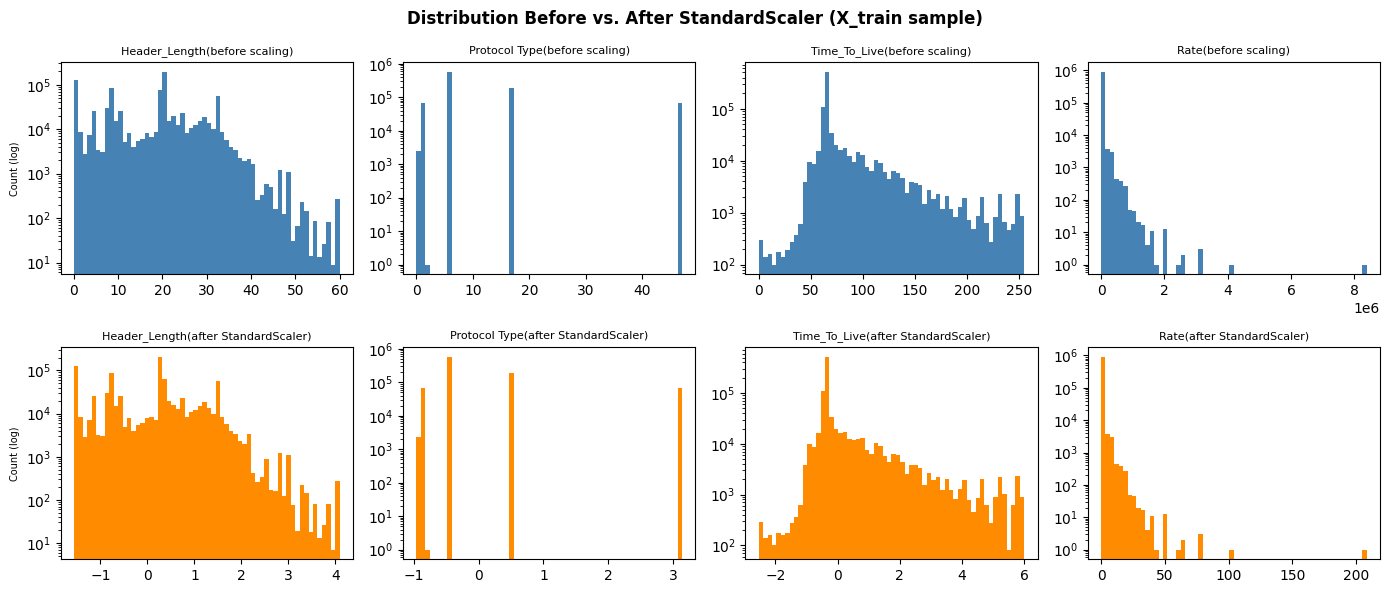

In [24]:
# Visualize before/after scaling for the first 4 numeric features
_preview_cols = numeric_feature_cols[:4]

fig, axes = plt.subplots(2, len(_preview_cols), figsize=(14, 6))

for j, col in enumerate(_preview_cols):
    # Before
    axes[0, j].hist(X_train_raw[col].dropna(), bins=60,
                    color="steelblue", edgecolor="none", log=True)
    axes[0, j].set_title(f"{col}(before scaling)", fontsize=8)
    axes[0, j].set_ylabel("Count (log)" if j == 0 else "", fontsize=7)

    # After
    axes[1, j].hist(X_train_scaled[col].dropna(), bins=60,
                    color="darkorange", edgecolor="none", log=True)
    axes[1, j].set_title(f"{col}(after StandardScaler)", fontsize=8)
    axes[1, j].set_ylabel("Count (log)" if j == 0 else "", fontsize=7)

fig.suptitle(
    "Distribution Before vs. After StandardScaler (X_train sample)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()
del _preview_cols, fig, axes

# Step 10 - Verify All Variants

Check that all feature variants have matching shapes. The values may differ, but the row and column structure should stay aligned.

The code below prints the shapes of every saved variant to confirm they still align.

In [25]:
print("RAW branch")
print("  Train:", X_train_raw.shape)
print("  Val  :", X_val_raw.shape)
print("  Test :", X_test_raw.shape)

print("\nOUTLIER branch")
print("  Train:", X_train_out.shape)
print("  Val  :", X_val_out.shape)
print("  Test :", X_test_out.shape)

print("\nSCALED branch")
print("  Train:", X_train_scaled.shape)
print("  Val  :", X_val_scaled.shape)
print("  Test :", X_test_scaled.shape)

print("\nOUTLIER + SCALED branch")
print("  Train:", X_train_out_scaled.shape)
print("  Val  :", X_val_out_scaled.shape)
print("  Test :", X_test_out_scaled.shape)

RAW branch
  Train: (901868, 39)
  Val  : (193258, 39)
  Test : (193258, 39)

OUTLIER branch
  Train: (901868, 39)
  Val  : (193258, 39)
  Test : (193258, 39)

SCALED branch
  Train: (901868, 39)
  Val  : (193258, 39)
  Test : (193258, 39)

OUTLIER + SCALED branch
  Train: (901868, 39)
  Val  : (193258, 39)
  Test : (193258, 39)


# Step 11 - Feature Selection Checks

Look for weak or redundant features using constant checks, correlation, and mutual information. The goal is to understand the feature set before training.

The code below runs feature-selection checks but keeps the feature set consistent for later experiments.

## Method 1 - Constant and Near-Constant Features

Find columns with no useful variation. If a feature barely changes, it usually cannot help separate classes.

The code below lists columns with one or very few unique values.

In [26]:
feature_cols_train = X_train_raw.columns.tolist()
numeric_cols_train = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()

print(f"Total feature columns   : {len(feature_cols_train)}")
print(f"Numeric feature columns : {len(numeric_cols_train)}")

Total feature columns   : 39
Numeric feature columns : 39


In [27]:
constant_cols = [c for c in numeric_cols_train if X_train_raw[c].nunique(dropna=True) <= 1]

print("=== CONSTANT COLUMNS (nunique <= 1) ===")
print(f"Count: {len(constant_cols)}")

if constant_cols:
    print("Columns:")
    print(constant_cols)
else:
    print("None found.")

=== CONSTANT COLUMNS (nunique <= 1) ===
Count: 0
None found.


In [28]:
DOMINANCE_THRESHOLD = 0.995   # 99.5%

near_constant_info = []

for col in numeric_cols_train:
    value_freq = X_train_raw[col].value_counts(normalize=True, dropna=False)

    if len(value_freq) == 0:
        continue

    top_freq = value_freq.iloc[0]

    if top_freq >= DOMINANCE_THRESHOLD:
        top_val = value_freq.index[0]

        near_constant_info.append({
            "column": col,
            "dominant_value": top_val,
            "dominant_pct": round(top_freq * 100, 4),
            "n_unique": X_train_raw[col].nunique(dropna=True)
        })

near_constant_df = pd.DataFrame(near_constant_info)

if not near_constant_df.empty:
    near_constant_df = (
        near_constant_df
        .sort_values(by="dominant_pct", ascending=False)
        .reset_index(drop=True)
    )

print(f"=== NEAR-CONSTANT COLUMNS (dominant value >= {DOMINANCE_THRESHOLD*100:.1f}%) ===")
print(f"Count: {len(near_constant_df)}")

display(near_constant_df)

=== NEAR-CONSTANT COLUMNS (dominant value >= 99.5%) ===
Count: 6


,column,dominant_value,dominant_pct,n_unique
0,SMTP,0.0,99.8699,10
1,Telnet,0.0,99.8656,10
2,cwr_flag_number,0.0,99.8431,20
3,IRC,0.0,99.8078,10
4,IGMP,0.0,99.7353,10
5,ece_flag_number,0.0,99.7324,25


In [29]:
safe_drop_candidates = sorted(constant_cols)

review_drop_candidates = (
    sorted(near_constant_df["column"].tolist())
    if not near_constant_df.empty else []
)

print("=== SAFE DROP CANDIDATES ===")
print(f"Count: {len(safe_drop_candidates)}")
print(safe_drop_candidates if safe_drop_candidates else "None")

print("\n=== REVIEW DROP CANDIDATES ===")
print(f"Count: {len(review_drop_candidates)}")
print(review_drop_candidates if review_drop_candidates else "None")

=== SAFE DROP CANDIDATES ===
Count: 0
None

=== REVIEW DROP CANDIDATES ===
Count: 6
['IGMP', 'IRC', 'SMTP', 'Telnet', 'cwr_flag_number', 'ece_flag_number']


## Method 2 - High Correlation

Find feature pairs that carry very similar information. Strongly correlated features may be redundant, especially for linear models.

The code below computes Pearson correlations and extracts highly correlated feature pairs.

In [30]:
CORR_THRESHOLD = 0.95

numeric_cols_corr = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()

corr_matrix = X_train_raw[numeric_cols_corr].corr(method="pearson").abs()

print(f"Correlation threshold : |r| >= {CORR_THRESHOLD}")
print(f"Numeric features used : {len(numeric_cols_corr)}")
print(f"Correlation matrix shape: {corr_matrix.shape}")

Correlation threshold : |r| >= 0.95
Numeric features used : 39
Correlation matrix shape: (39, 39)


## Upper-Triangle Correlation Matrix

Use only the upper triangle of the correlation matrix so each pair appears once. This makes the correlation table easier to inspect.

The code below displays only the upper triangle so duplicate correlation pairs are not repeated.

In [31]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

display(upper.head(10))

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance
Header_Length,NaN,0.527905,0.304224,0.029372,0.117462,0.261711,0.156248,0.350405,0.685210,0.027059,...,0.027837,0.468921,0.123770,0.182816,0.109008,0.182301,0.109008,0.000452,0.429623,0.153499
Protocol Type,NaN,NaN,0.121350,0.074289,0.108684,0.211847,0.147357,0.189534,0.326501,0.010750,...,0.058797,0.319209,0.284134,0.057909,0.164586,0.159031,0.164586,0.000380,0.179899,0.091219
Time_To_Live,NaN,NaN,NaN,0.116315,0.066991,0.134883,0.002523,0.194050,0.429564,0.022688,...,0.041765,0.194474,0.048041,0.118523,0.068150,0.130604,0.068150,0.000168,0.506824,0.082278
Rate,NaN,NaN,NaN,NaN,0.053822,0.108108,0.077271,0.030618,0.075730,0.007167,...,0.086853,0.150367,0.048072,0.154481,0.172382,0.157830,0.172382,0.000577,0.056757,0.067507
fin_flag_number,NaN,NaN,NaN,NaN,NaN,0.106403,0.772481,0.070508,0.098293,0.002985,...,0.038469,0.129252,0.069184,0.097675,0.150112,0.102112,0.150112,0.000151,0.087920,0.044351
syn_flag_number,NaN,NaN,NaN,NaN,NaN,NaN,0.046150,0.174292,0.202734,0.004786,...,0.082945,0.250219,0.135093,0.199924,0.301160,0.217499,0.301160,0.000502,0.118197,0.097153
rst_flag_number,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.092388,0.009482,0.007392,...,0.066526,0.154985,0.092873,0.119290,0.194075,0.130488,0.194075,0.000564,0.050644,0.057482
psh_flag_number,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.635421,0.011256,...,0.054183,0.170644,0.010053,0.086427,0.008257,0.083329,0.008257,0.000443,0.198771,0.057734
ack_flag_number,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.022886,...,0.061860,0.168383,0.006062,0.351522,0.194756,0.378019,0.194756,0.000426,0.542385,0.232534
ece_flag_number,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.008342,0.013708,0.008057,0.007829,0.002535,0.011006,0.002535,0.000047,0.037006,0.006439


In [32]:
correlated_drop_candidates = [
    col for col in upper.columns
    if any(upper[col] >= CORR_THRESHOLD)
]

print(f"=== HIGH-CORRELATION CANDIDATES (|r| >= {CORR_THRESHOLD}) ===")
print(f"Count: {len(correlated_drop_candidates)}")

if correlated_drop_candidates:
    print("Candidate features to review:")
    for col in correlated_drop_candidates:
        max_corr_val = upper[col].max()
        max_corr_feat = upper[col].idxmax()
        print(f"  {col:<30s}  |r|={max_corr_val:.4f}  with  {max_corr_feat}")
else:
    print("No features exceeded the correlation threshold.")

=== HIGH-CORRELATION CANDIDATES (|r| >= 0.95) ===
Count: 4
Candidate features to review:
  fin_count                       |r|=0.9865  with  fin_flag_number
  IPv                             |r|=1.0000  with  ARP
  LLC                             |r|=1.0000  with  ARP
  Tot size                        |r|=1.0000  with  AVG


In [33]:
corr_pairs = []

for col in upper.columns:
    high_corr_rows = upper.index[upper[col] >= CORR_THRESHOLD].tolist()
    for other_col in high_corr_rows:
        corr_pairs.append({
            "feature_to_review": col,
            "kept_reference_feature": other_col,
            "abs_correlation": round(upper.loc[other_col, col], 6)
        })

corr_pairs_df = pd.DataFrame(corr_pairs).sort_values(
    by="abs_correlation", ascending=False
).reset_index(drop=True)

display(corr_pairs_df.head(20))

,feature_to_review,kept_reference_feature,abs_correlation
0,IPv,ARP,1.000000
1,LLC,IPv,1.000000
2,LLC,ARP,1.000000
3,Tot size,AVG,1.000000
4,fin_count,fin_flag_number,0.986537


## Correlation Heatmap

The heatmap gives a quick visual view of correlated feature groups. Blocks of similar color usually mean related or redundant features.

The code below plots the correlation matrix to make correlated feature groups easier to spot.

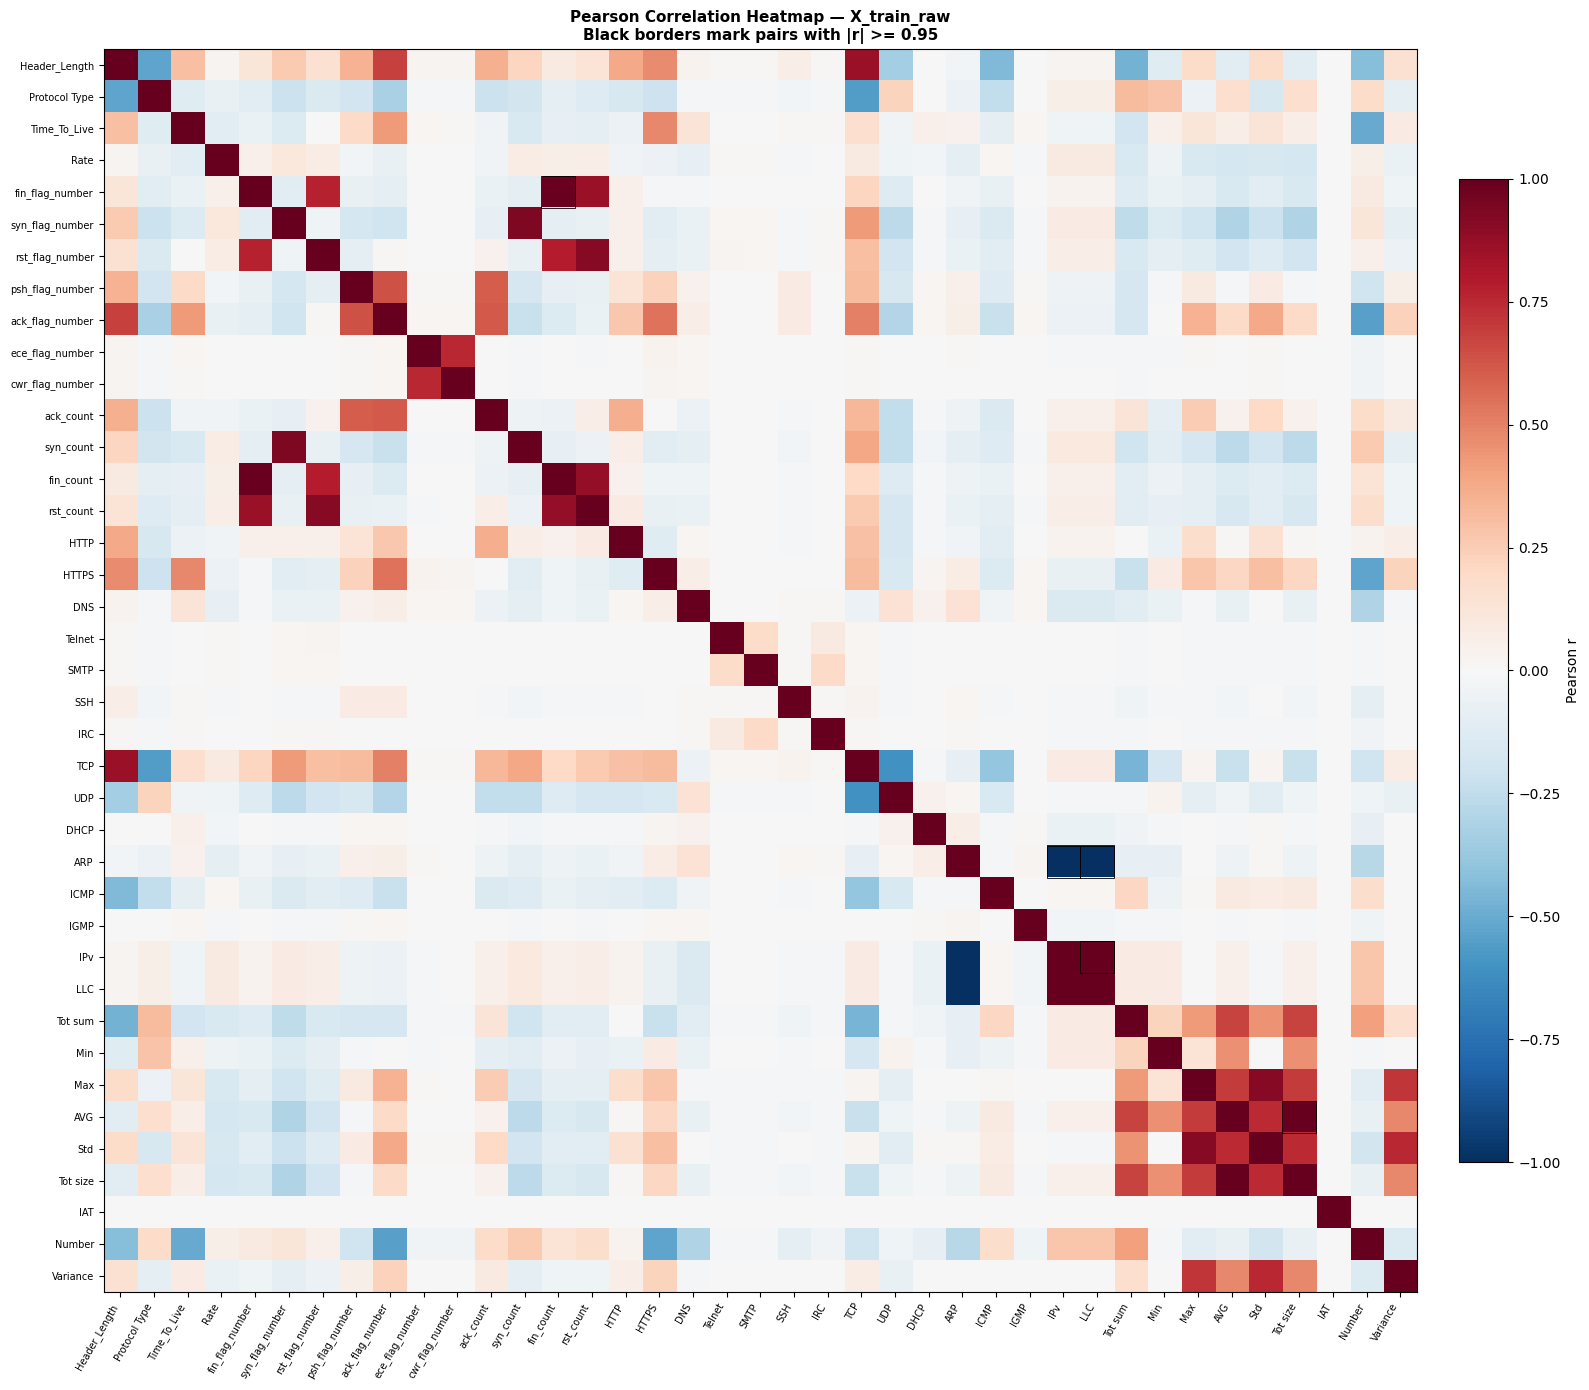

In [34]:
# Correlation heatmap of all training features
_corr = X_train_raw.corr(method="pearson")

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(_corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.035, pad=0.03, label="Pearson r")

_labels = _corr.columns.tolist()
ax.set_xticks(range(len(_labels)))
ax.set_yticks(range(len(_labels)))
ax.set_xticklabels(_labels, rotation=60, ha="right", fontsize=7)
ax.set_yticklabels(_labels, fontsize=7)

# Draw the threshold boundary (purely visual guide lines at pairs >= 0.95)
for i in range(len(_labels)):
    for j in range(i + 1, len(_labels)):
        if abs(_corr.iloc[i, j]) >= CORR_THRESHOLD:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                         fill=False, edgecolor="black", linewidth=0.6))

ax.set_title(
    f"Pearson Correlation Heatmap — X_train_raw\n"
    f"Black borders mark pairs with |r| >= {CORR_THRESHOLD}",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.show()
del _corr, _labels, fig, ax, im

## Method 3 - Mutual Information

Mutual information estimates how much each feature helps explain the target. It is useful because it can capture non-linear relationships.

The code below computes mutual information scores and ranks features by their relationship with the label.

In [35]:
MI_THRESHOLD = 0.01   # candidate threshold only

# Choose the branch you want to evaluate
X_train_mi = X_train_raw.copy()

print("Computing mutual information on X_train_raw — this may take a minute...")

mi_scores = mutual_info_classif(
    X_train_mi,
    y_train_encoded,
    discrete_features=False,
    random_state=RANDOM_STATE
)

mi_series = pd.Series(mi_scores, index=X_train_mi.columns).sort_values(ascending=False)

print(f"Done. Features evaluated: {len(mi_series)}")
print(f"MI score range: [{mi_series.min():.4f}, {mi_series.max():.4f}]")
print("\nAll MI scores (sorted descending):")
print(mi_series.to_string())

Computing mutual information on X_train_raw — this may take a minute...


Done. Features evaluated: 39
MI score range: [0.0011, 1.6055]

All MI scores (sorted descending):
Header_Length      1.605535
Tot sum            1.565358
AVG                1.398735
Tot size           1.398577
Max                1.321131
Variance           1.082330
Std                1.082159
TCP                0.993457
ack_flag_number    0.882318
Protocol Type      0.865894
ack_count          0.842696
UDP                0.796609
syn_flag_number    0.702196
Rate               0.699691
IAT                0.695874
Time_To_Live       0.670050
Number             0.621922
psh_flag_number    0.615663
syn_count          0.609945
Min                0.589315
HTTPS              0.457196
rst_flag_number    0.379389
ICMP               0.371228
fin_flag_number    0.354369
rst_count          0.350084
fin_count          0.291472
HTTP               0.284543
LLC                0.194537
IPv                0.192898
ARP                0.186757
DNS                0.150524
SSH                0.024586
DHCP  

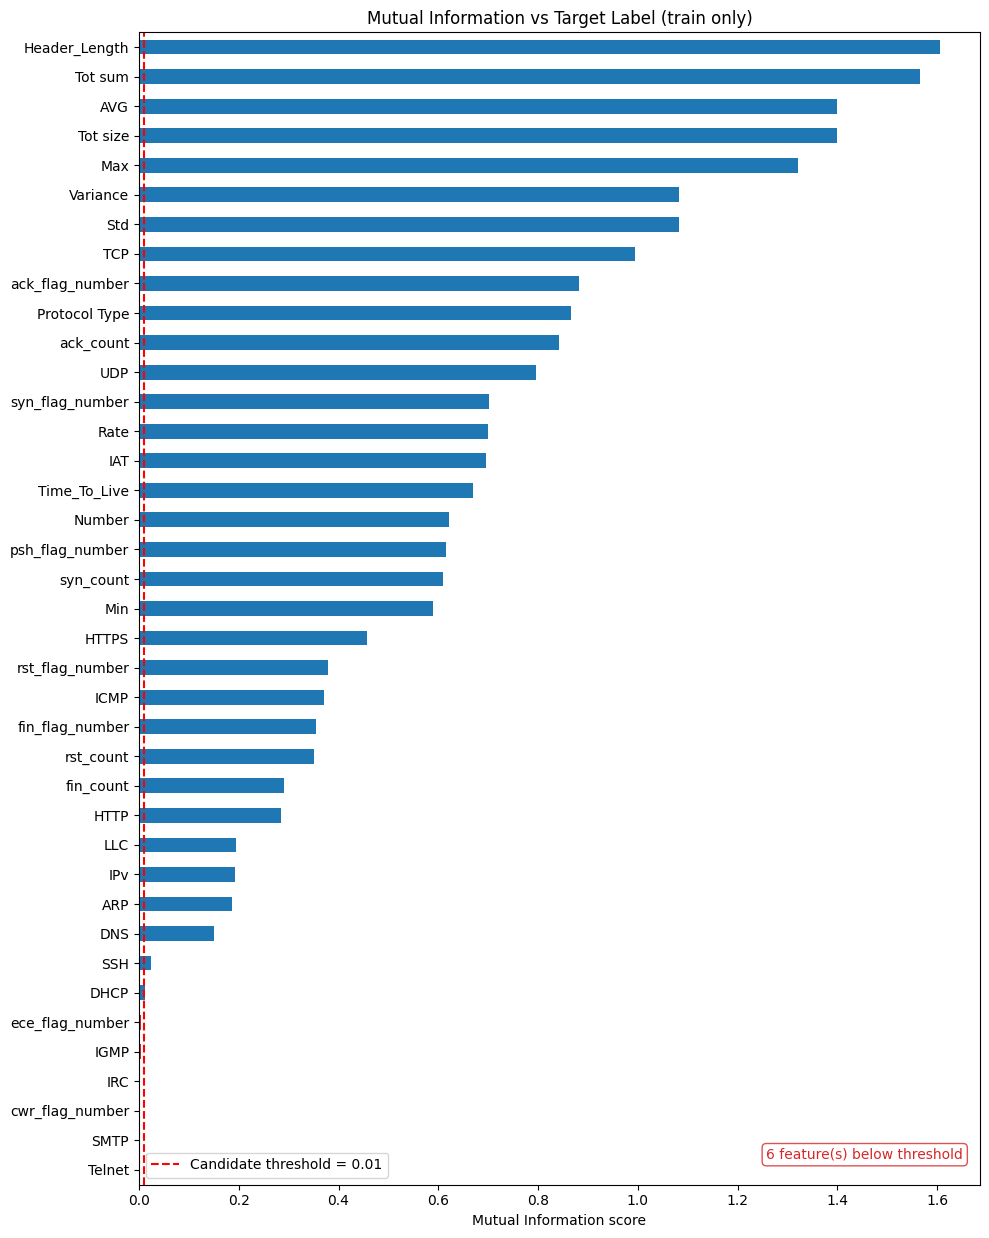

In [36]:
fig, ax = plt.subplots(figsize=(10, max(6, len(mi_series) * 0.32)))

colors = ["#d62728" if v < MI_THRESHOLD else "#1f77b4" for v in mi_series.sort_values()]

mi_series.sort_values().plot(
    kind="barh",
    ax=ax,
    color=colors,
    edgecolor="none"
)

ax.axvline(
    MI_THRESHOLD,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Candidate threshold = {MI_THRESHOLD}"
)

ax.set_xlabel("Mutual Information score")
ax.set_title("Mutual Information vs Target Label (train only)")
ax.legend()

n_low = (mi_series < MI_THRESHOLD).sum()
ax.text(
    0.98, 0.02,
    f"{n_low} feature(s) below threshold",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    color="#d62728",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d62728", alpha=0.8)
)

plt.tight_layout()
plt.show()

In [37]:
mi_drop_candidates = mi_series[mi_series < MI_THRESHOLD].index.tolist()

print(f"Features below threshold ({MI_THRESHOLD}):")
print(mi_drop_candidates if mi_drop_candidates else "None")

Features below threshold (0.01):
['ece_flag_number', 'IGMP', 'IRC', 'cwr_flag_number', 'SMTP', 'Telnet']


# Step 12 - Skewness Transformation

Check highly skewed features and decide whether a transformation is useful. This mainly helps models that assume smoother numeric distributions.

The code below identifies highly skewed numeric columns and prepares transformation choices.

In [38]:
SKEW_THRESHOLD = 1.0   # |skewness| above this → candidate for transformation

numeric_cols_skew = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()

skew_series = X_train_raw[numeric_cols_skew].skew()
min_series  = X_train_raw[numeric_cols_skew].min()

skew_df = pd.DataFrame({
    "skewness": skew_series,
    "train_min": min_series,
    "abs_skew": skew_series.abs()
}).sort_values("abs_skew", ascending=False)

display(skew_df.head(20))

,skewness,train_min,abs_skew
IAT,868.228008,3.814697e-07,868.228008
SMTP,94.306934,0.000000e+00,94.306934
cwr_flag_number,84.580773,0.000000e+00,84.580773
Telnet,81.483716,0.000000e+00,81.483716
IRC,79.223533,0.000000e+00,79.223533
ece_flag_number,63.590983,0.000000e+00,63.590983
IGMP,35.534479,0.000000e+00,35.534479
Variance,29.620910,0.000000e+00,29.620910
Rate,26.058107,2.142924e-05,26.058107
DHCP,20.861372,0.000000e+00,20.861372


In [39]:
highly_skewed = skew_df[skew_df["abs_skew"] > SKEW_THRESHOLD].copy()

print(f"Skewness threshold    : |skew| > {SKEW_THRESHOLD}")
print(f"Total numeric features: {len(numeric_cols_skew)}")
print(f"Highly skewed total   : {len(highly_skewed)}")

display(highly_skewed.head(20))

Skewness threshold    : |skew| > 1.0
Total numeric features: 39
Highly skewed total   : 35


,skewness,train_min,abs_skew
IAT,868.228008,3.814697e-07,868.228008
SMTP,94.306934,0.000000e+00,94.306934
cwr_flag_number,84.580773,0.000000e+00,84.580773
Telnet,81.483716,0.000000e+00,81.483716
IRC,79.223533,0.000000e+00,79.223533
ece_flag_number,63.590983,0.000000e+00,63.590983
IGMP,35.534479,0.000000e+00,35.534479
Variance,29.620910,0.000000e+00,29.620910
Rate,26.058107,2.142924e-05,26.058107
DHCP,20.861372,0.000000e+00,20.861372


## Choose log1p or Yeo-Johnson

Use `log1p` for non-negative skewed features. Use Yeo-Johnson only when a feature can contain negative values.

The code below chooses `log1p` or Yeo-Johnson based on whether each feature contains negative values.

In [40]:
log1p_features = highly_skewed[highly_skewed["train_min"] >= 0].index.tolist()
yj_features    = highly_skewed[highly_skewed["train_min"] < 0].index.tolist()

print(f"log1p candidates      : {len(log1p_features)}")
print(f"Yeo-Johnson candidates: {len(yj_features)}")

print("\nlog1p candidates:")
print(log1p_features if log1p_features else "None")

print("\nYeo-Johnson candidates:")
print(yj_features if yj_features else "None")

log1p candidates      : 35
Yeo-Johnson candidates: 0

log1p candidates:
['IAT', 'SMTP', 'cwr_flag_number', 'Telnet', 'IRC', 'ece_flag_number', 'IGMP', 'Variance', 'Rate', 'DHCP', 'SSH', 'ARP', 'IPv', 'LLC', 'DNS', 'Min', 'fin_count', 'fin_flag_number', 'Max', 'rst_count', 'rst_flag_number', 'Time_To_Live', 'ICMP', 'Std', 'psh_flag_number', 'HTTP', 'Protocol Type', 'syn_count', 'ack_count', 'Tot size', 'AVG', 'syn_flag_number', 'HTTPS', 'UDP', 'Tot sum']

Yeo-Johnson candidates:
None


In [41]:
skew_transform_plan = pd.DataFrame({
    "feature": log1p_features + yj_features,
    "proposed_transform": (["log1p"] * len(log1p_features)) + (["yeo-johnson"] * len(yj_features))
})

display(skew_transform_plan)

,feature,proposed_transform
0,IAT,log1p
1,SMTP,log1p
2,cwr_flag_number,log1p
3,Telnet,log1p
4,IRC,log1p
5,ece_flag_number,log1p
6,IGMP,log1p
7,Variance,log1p
8,Rate,log1p
9,DHCP,log1p


# Step 13 - Class Weights

Compute class weights to reduce the effect of imbalance. Rare classes receive higher weight so models do not ignore them.

The code below computes balanced class weights from the encoded training labels.

In [42]:
classes = np.unique(y_train_encoded)

raw_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_encoded
)

class_weight_dict = dict(zip(classes.tolist(), raw_weights.tolist()))

weight_df = pd.DataFrame({
    "class_idx": classes,
    "class_name": [label_encoder.classes_[i] for i in classes],
    "n_train": [(y_train_encoded == i).sum() for i in classes],
    "weight": raw_weights
}).sort_values("weight", ascending=False).reset_index(drop=True)

weight_df["weight"] = weight_df["weight"].round(4)

print(f"Classes      : {len(classes)}")
print(f"Total train  : {len(y_train_encoded):,}")
print(f"Weight range : [{raw_weights.min():.4f}, {raw_weights.max():.4f}]")
print()

display(weight_df)

Classes      : 34
Total train  : 901,868
Weight range : [0.7579, 31.6912]



,class_idx,class_name,n_train,weight
0,31,UPLOADING_ATTACK,837,31.6912
1,28,RECON-PINGSWEEP,1513,17.5317
2,0,BACKDOOR_MALWARE,2152,12.3260
3,33,XSS,2593,10.2297
4,30,SQLINJECTION,3515,7.5464
5,3,COMMANDINJECTION,3605,7.3580
6,2,BROWSERHIJACKING,3892,6.8154
7,16,DICTIONARYBRUTEFORCE,8764,3.0266
8,10,DDOS-SLOWLORIS,15679,1.6918
9,5,DDOS-HTTP_FLOOD,19318,1.3731


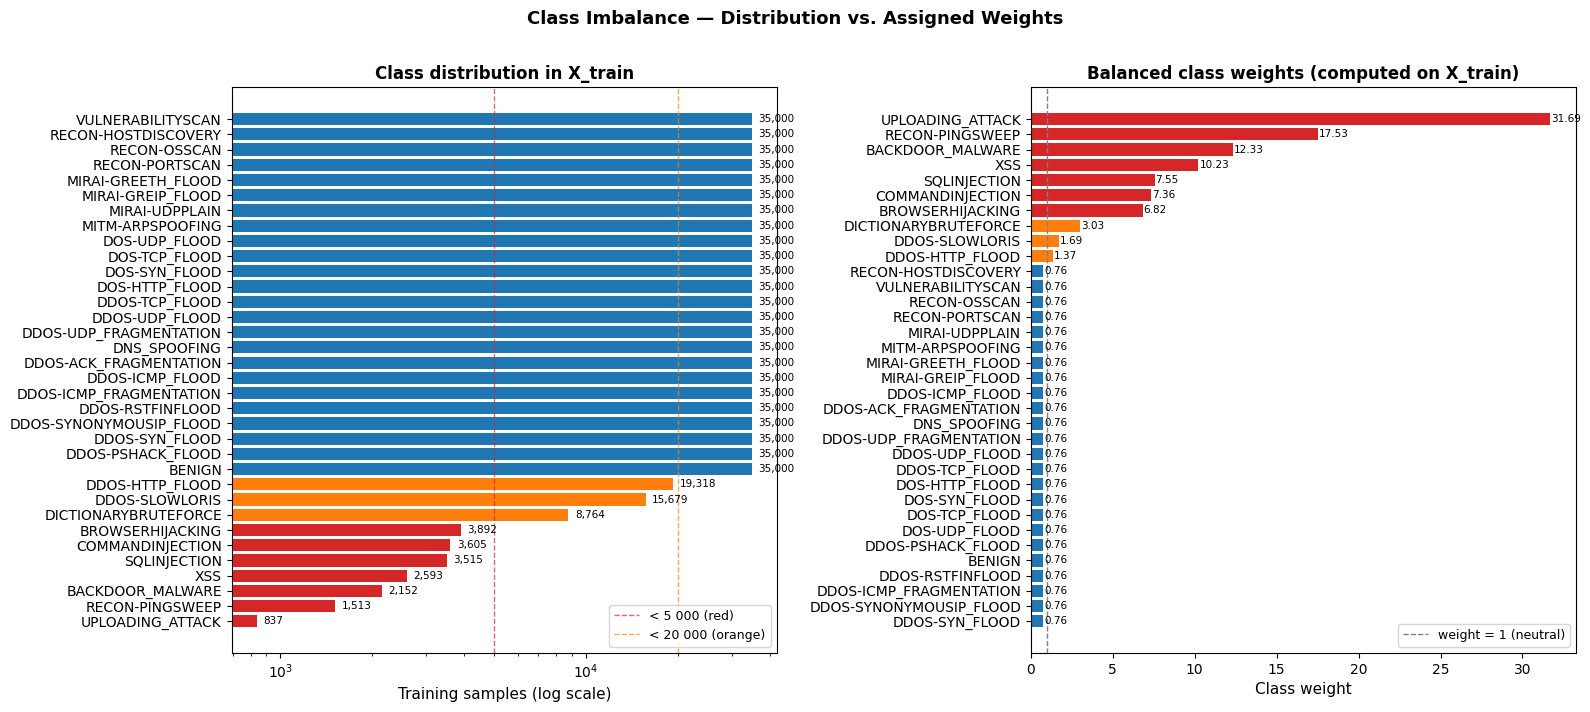

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
 
# ── Left: training sample counts (log scale) ────────────────────────────────
plot_df = weight_df.sort_values("n_train", ascending=True)
 
bar_colors_count = [
    "#d62728" if n < 5000 else "#ff7f0e" if n < 20000 else "#1f77b4"
    for n in plot_df["n_train"]
]
axes[0].barh(plot_df["class_name"], plot_df["n_train"],
             color=bar_colors_count, edgecolor="none")
axes[0].set_xscale("log")
axes[0].set_xlabel("Training samples (log scale)", fontsize=11)
axes[0].set_title("Class distribution in X_train", fontsize=12, fontweight="bold")
axes[0].axvline(5000,  color="#d62728",  linestyle="--", linewidth=1, alpha=0.7, label="< 5 000 (red)")
axes[0].axvline(20000, color="#ff7f0e", linestyle="--", linewidth=1, alpha=0.7, label="< 20 000 (orange)")
axes[0].legend(fontsize=9)
for i, (n, name) in enumerate(zip(plot_df["n_train"], plot_df["class_name"])):
    axes[0].text(n * 1.05, i, f"{n:,}", va="center", fontsize=7.5)
 
# ── Right: assigned class weights ────────────────────────────────────────────
plot_df2 = weight_df.sort_values("weight", ascending=True)
 
bar_colors_w = [
    "#d62728" if w > 5 else "#ff7f0e" if w > 1 else "#1f77b4"
    for w in plot_df2["weight"]
]
axes[1].barh(plot_df2["class_name"], plot_df2["weight"],
             color=bar_colors_w, edgecolor="none")
axes[1].axvline(1.0, color="grey", linestyle="--", linewidth=1, label="weight = 1 (neutral)")
axes[1].set_xlabel("Class weight", fontsize=11)
axes[1].set_title("Balanced class weights (computed on X_train)", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)
for i, (w, name) in enumerate(zip(plot_df2["weight"], plot_df2["class_name"])):
    axes[1].text(w + 0.05, i, f"{w:.2f}", va="center", fontsize=7.5)
 
plt.suptitle("Class Imbalance — Distribution vs. Assigned Weights", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Build Sample Weights

Create one weight per training row based on its class. Some models can use these weights directly during fitting.

The code below maps each training row to the weight of its class.

In [44]:
sample_weights = np.array([class_weight_dict[c] for c in y_train_encoded])

print(f"sample_weights shape : {sample_weights.shape}")
print(f"sample_weights dtype : {sample_weights.dtype}")
print(f"Min weight in array  : {sample_weights.min():.4f}")
print(f"Max weight in array  : {sample_weights.max():.4f}")

sample_weights shape : (901868,)
sample_weights dtype : float64
Min weight in array  : 0.7579
Max weight in array  : 31.6912


# Step 14 - Save Outputs

Save the processed splits, encoded labels, class weights, and metadata. The training notebooks load these files directly.

The code below saves processed feature CSVs, encoded labels, weights, and comparison metadata.

In [45]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
ARTIFACTS_DIR = PROJECT_ROOT / "data" / "artifacts"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Processed dir:", PROCESSED_DIR)
print("Artifacts dir:", ARTIFACTS_DIR)


# Save target splits
pd.Series(y_train_encoded, name="Label").to_csv(PROCESSED_DIR / "y_train_encoded.csv", index=False)
pd.Series(y_val_encoded,   name="Label").to_csv(PROCESSED_DIR / "y_val_encoded.csv", index=False)
pd.Series(y_test_encoded,  name="Label").to_csv(PROCESSED_DIR / "y_test_encoded.csv", index=False)
print("\nSaved encoded target splits.")


# Save all feature-set variants
# RAW
X_train_raw.to_csv(PROCESSED_DIR / "X_train_raw.csv", index=False)
X_val_raw.to_csv(PROCESSED_DIR   / "X_val_raw.csv",   index=False)
X_test_raw.to_csv(PROCESSED_DIR  / "X_test_raw.csv",  index=False)

# OUTLIER ONLY
X_train_out.to_csv(PROCESSED_DIR / "X_train_out.csv", index=False)
X_val_out.to_csv(PROCESSED_DIR   / "X_val_out.csv",   index=False)
X_test_out.to_csv(PROCESSED_DIR  / "X_test_out.csv",  index=False)

# SCALED ONLY
X_train_scaled.to_csv(PROCESSED_DIR / "X_train_scaled.csv", index=False)
X_val_scaled.to_csv(PROCESSED_DIR   / "X_val_scaled.csv",   index=False)
X_test_scaled.to_csv(PROCESSED_DIR  / "X_test_scaled.csv",  index=False)

# OUTLIER + SCALED
X_train_out_scaled.to_csv(PROCESSED_DIR / "X_train_out_scaled.csv", index=False)
X_val_out_scaled.to_csv(PROCESSED_DIR   / "X_val_out_scaled.csv",   index=False)
X_test_out_scaled.to_csv(PROCESSED_DIR  / "X_test_out_scaled.csv",  index=False)

print("Saved all feature-set variants.")


# Save label mapping
label_mapping_df = pd.DataFrame({
    "class_name": label_encoder.classes_,
    "class_id": list(range(len(label_encoder.classes_)))
})
label_mapping_df.to_csv(ARTIFACTS_DIR / "label_mapping.csv", index=False)

with open(ARTIFACTS_DIR / "label_mapping.json", "w") as f:
    json.dump(
        {cls: int(i) for i, cls in enumerate(label_encoder.classes_)},
        f, indent=2
    )
print("Saved label mapping.")


# Save class weights / sample weights if they exist
if "class_weight_dict" in globals():
    with open(ARTIFACTS_DIR / "class_weight_dict.json", "w") as f:
        json.dump({str(k): float(v) for k, v in class_weight_dict.items()}, f, indent=2)
    print("Saved class_weight_dict.json")

if "sample_weights" in globals():
    np.save(ARTIFACTS_DIR / "sample_weights_train.npy", sample_weights)
    print("Saved sample_weights_train.npy")


# Save scalers if they exist
if "scaler_raw" in globals():
    with open(ARTIFACTS_DIR / "scaler_raw.pkl", "wb") as f:
        pickle.dump(scaler_raw, f)
    print("Saved scaler_raw.pkl")

if "scaler_out" in globals():
    with open(ARTIFACTS_DIR / "scaler_out.pkl", "wb") as f:
        pickle.dump(scaler_out, f)
    print("Saved scaler_out.pkl")


# Save candidate lists / preprocessing decisions
candidate_lists = {
    "constant_cols":             constant_cols             if "constant_cols"             in globals() else [],
    "safe_drop_candidates":      safe_drop_candidates      if "safe_drop_candidates"      in globals() else [],
    "review_drop_candidates":    review_drop_candidates    if "review_drop_candidates"    in globals() else [],
    "correlated_drop_candidates":correlated_drop_candidates if "correlated_drop_candidates" in globals() else [],
    "log1p_features":            log1p_features            if "log1p_features"            in globals() else [],
    "yj_features":               yj_features               if "yj_features"               in globals() else [],
    "clip_candidates":           clip_candidates           if "clip_candidates"           in globals() else [],
    "numeric_feature_cols":      numeric_feature_cols      if "numeric_feature_cols"      in globals() else [],
    "skew_transform_plan": (
        skew_transform_plan.to_dict(orient="records")
        if "skew_transform_plan" in globals() else []
    )
}

with open(ARTIFACTS_DIR / "candidate_lists.json", "w") as f:
    json.dump(candidate_lists, f, indent=2)

print("Saved candidate_lists.json")

Processed dir: C:\Users\user\Desktop\MyFiles\Uni\My_ML_Project\data\processed
Artifacts dir: C:\Users\user\Desktop\MyFiles\Uni\My_ML_Project\data\artifacts



Saved encoded target splits.


Saved all feature-set variants.
Saved label mapping.
Saved class_weight_dict.json
Saved sample_weights_train.npy
Saved scaler_raw.pkl
Saved scaler_out.pkl
Saved candidate_lists.json


# Step 15 - Save Deployment Artifacts

Save the feature list, label mapping, scalers, and clipping bounds used by the API. This lets the deployed service apply the same preprocessing as training.

The code below saves the exact feature order, label mapping, scalers, and IQR bounds for the API.

In [46]:
# Save IQR bounds (for out / out_scaled inference) and feature column order.
iqr_bounds = {
    "clip_candidates": list(clip_candidates),
    "lower": {col: float(lower_bounds[col]) for col in clip_candidates},
    "upper": {col: float(upper_bounds[col]) for col in clip_candidates},
}

with open(ARTIFACTS_DIR / "iqr_bounds.json", "w") as f:
    json.dump(iqr_bounds, f, indent=2)
print("Saved iqr_bounds.json")

feature_names = list(X_train_raw.columns)
with open(ARTIFACTS_DIR / "feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)
print(f"Saved feature_names.json ({len(feature_names)} features)")

Saved iqr_bounds.json
Saved feature_names.json (39 features)
